In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

from sklearn.datasets import fetch_california_housing

%matplotlib inline

In [2]:
data = fetch_california_housing(as_frame=True)
df = data.frame

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Matplotlib

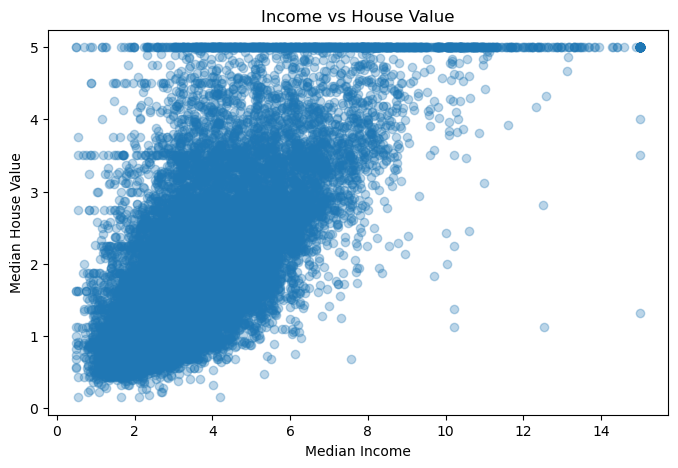

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Income vs House Value")
plt.show()

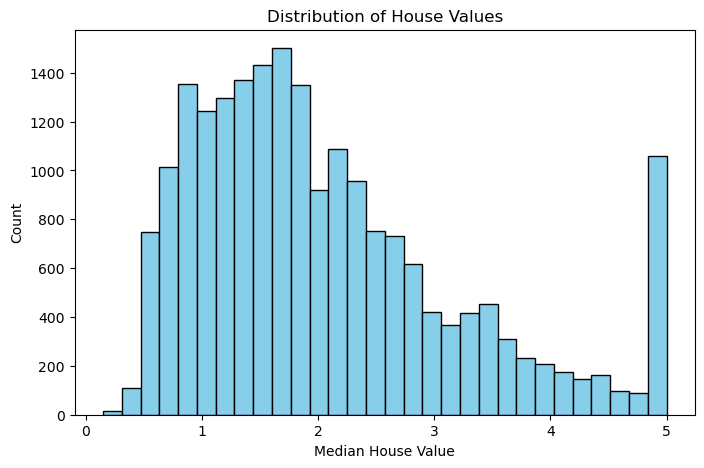

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["MedHouseVal"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.title("Distribution of House Values")
plt.show()

## Seaborn

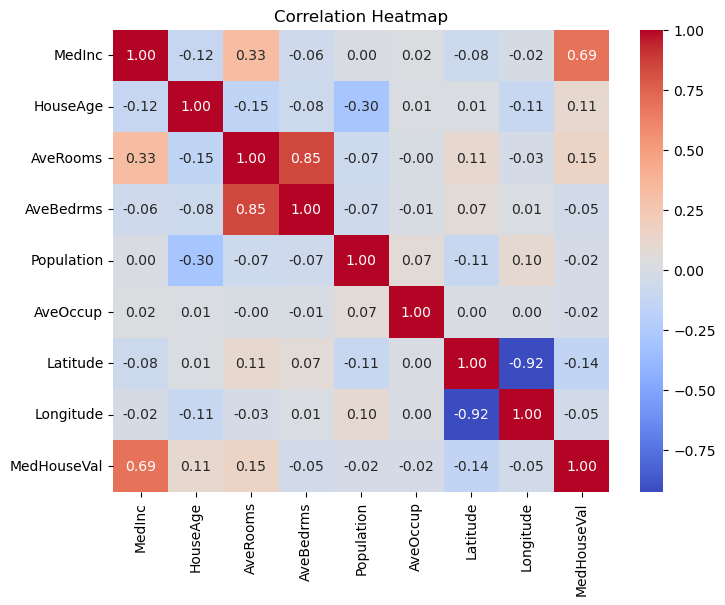

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

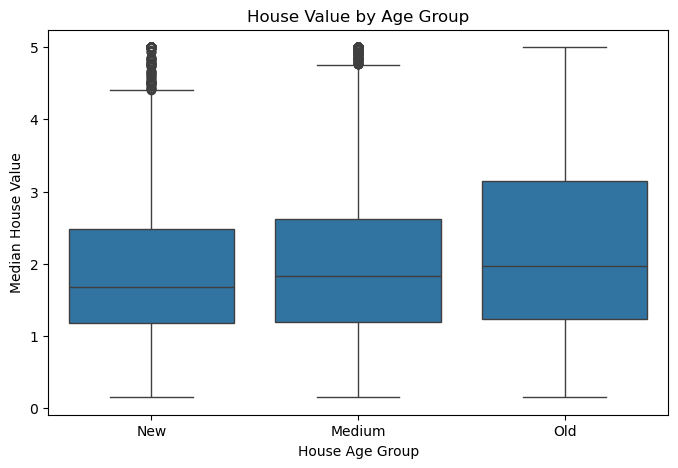

In [7]:
df["AgeGroup"] = pd.cut(df["HouseAge"], bins=[0, 20, 40, 60], labels=["New", "Medium", "Old"])

plt.figure(figsize=(8, 5))
sns.boxplot(x="AgeGroup", y="MedHouseVal", data=df)
plt.xlabel("House Age Group")
plt.ylabel("Median House Value")
plt.title("House Value by Age Group")
plt.show()

## Plotly

In [8]:
sample = df.sample(2000, random_state=42)

fig = px.scatter(
	sample,
	x="Longitude",
	y="Latitude",
	color="MedHouseVal",
	title="California Housing Map",
	labels={"MedHouseVal": "House Value"}
)
fig.show()

In [9]:
fig2 = px.scatter(
	sample,
	x="MedInc",
	y="MedHouseVal",
	color="HouseAge",
	title="Income vs House Value",
	labels={"MedInc": "Median Income", "MedHouseVal": "House Value", "HouseAge": "House Age"}
)
fig2.show()

## Altair

In [10]:
alt_df = df.sample(1500, random_state=42)

chart = alt.Chart(alt_df).mark_circle(opacity=0.5).encode(
		x="MedInc",
		y="MedHouseVal",
		color="HouseAge",
		tooltip=["MedInc", "MedHouseVal", "HouseAge", "AveRooms"]
).properties(
		title="Income vs House Value",
		width=500,
		height=350
).interactive()

chart

alt.Chart(...)

In [11]:
avg_by_age = df.groupby("AgeGroup", observed=True)["MedHouseVal"].mean().reset_index()

bar = alt.Chart(avg_by_age).mark_bar().encode(
		x="AgeGroup",
		y="MedHouseVal",
		tooltip=["AgeGroup", "MedHouseVal"]
).properties(
		title="Average House Value by Age Group",
		width=400,
		height=300
)

bar

alt.Chart(...)